# Exploratory Data Analysis (EDA)

This notebook focuses on exploring the processed customer churn dataset, identifying patterns related to churn, and extracting useful business insights for further modelling.

In [3]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

df = pd.read_csv(r"C:\Users\RATHICK A\OneDrive\Desktop\data analytics\data\telco_customer_churn_processed_for_modelling_with_target_leakage.csv")

In [5]:
df.head()

,Count,Zip Code,Latitude,Longitude,Gender,Senior Citizen,Partner,Dependents,Tenure Months,Phone Service,...,Contract_Month-to-month,Contract_One year,Contract_Two year,Payment Method_Bank transfer (automatic),Payment Method_Credit card (automatic),Payment Method_Electronic check,Payment Method_Mailed check,Tenure Group,Total Services,Support Services
0,1,90003,33.964131,-118.272783,1,0,0,0,2,1,...,1,0,0,0,0,0,1,New,3,2
1,1,90005,34.059281,-118.307420,0,0,0,1,2,1,...,1,0,0,0,0,1,0,New,1,0
2,1,90006,34.048013,-118.293953,0,0,0,1,8,1,...,1,0,0,0,0,1,0,New,5,1
3,1,90010,34.062125,-118.315709,0,0,1,1,28,1,...,1,0,0,0,0,1,0,Medium,6,2
4,1,90015,34.039224,-118.266293,1,0,0,1,49,1,...,1,0,0,1,0,0,0,Long-term,6,2


In [10]:
df.isnull().sum().sum()  #basic check 

np.int64(0)

In [11]:
df["Churn Label"].value_counts()

Churn Label
0    5174
1    1869
Name: count, dtype: int64

In [12]:
df["Churn Label"].value_counts(normalize=True) * 100

Churn Label
0    73.463013
1    26.536987
Name: proportion, dtype: float64

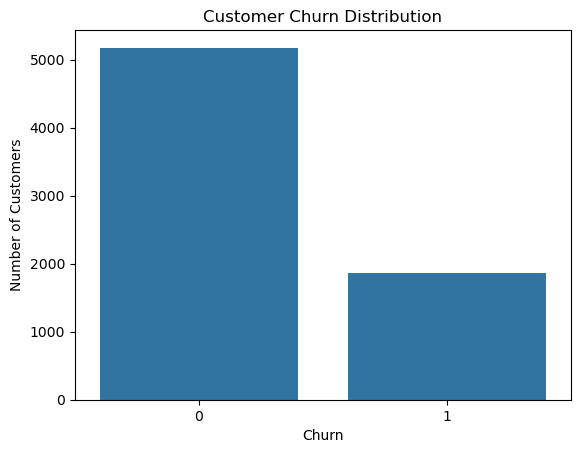

In [13]:
sns.countplot(data=df, x="Churn Label")
plt.title("Customer Churn Distribution")
plt.xlabel("Churn")
plt.ylabel("Number of Customers")
plt.show()

In [25]:
df.columns.tolist()

['Count',
 'Zip Code',
 'Latitude',
 'Longitude',
 'Gender',
 'Senior Citizen',
 'Partner',
 'Dependents',
 'Tenure Months',
 'Phone Service',
 'Paperless Billing',
 'Monthly Charges',
 'Total Charges',
 'Churn Label',
 'Churn Value',
 'Churn Score',
 'CLTV',
 'Multiple Lines_No',
 'Multiple Lines_No phone service',
 'Multiple Lines_Yes',
 'Internet Service_DSL',
 'Internet Service_Fiber optic',
 'Internet Service_No',
 'Online Security_No',
 'Online Security_No internet service',
 'Online Security_Yes',
 'Online Backup_No',
 'Online Backup_No internet service',
 'Online Backup_Yes',
 'Device Protection_No',
 'Device Protection_No internet service',
 'Device Protection_Yes',
 'Tech Support_No',
 'Tech Support_No internet service',
 'Tech Support_Yes',
 'Streaming TV_No',
 'Streaming TV_No internet service',
 'Streaming TV_Yes',
 'Streaming Movies_No',
 'Streaming Movies_No internet service',
 'Streaming Movies_Yes',
 'Contract_Month-to-month',
 'Contract_One year',
 'Contract_Two year'

In [26]:
eda_df = pd.read_csv(r"C:\Users\RATHICK A\OneDrive\Desktop\data analytics\data\telco_customer_churn_processed.csv")

In [27]:
pd.crosstab(
    eda_df["Contract"],
    eda_df["Churn Label"],
    normalize="index"
) * 100

Churn Label,No,Yes
Contract,,
Month-to-month,57.290323,42.709677
One year,88.730482,11.269518
Two year,97.168142,2.831858


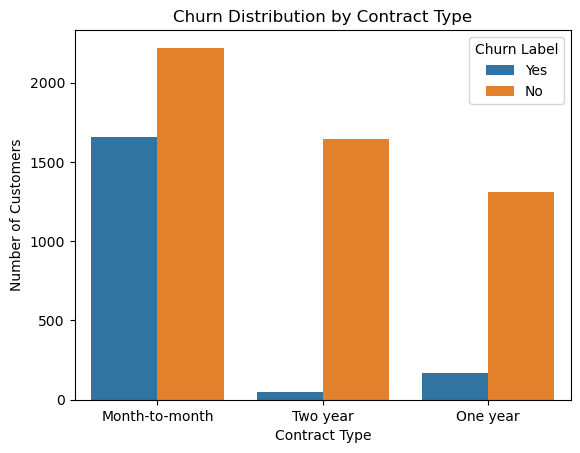

In [28]:
sns.countplot(data=eda_df, x="Contract", hue="Churn Label")

plt.title("Churn Distribution by Contract Type")
plt.xlabel("Contract Type")
plt.ylabel("Number of Customers")
plt.show()

In [29]:
pd.crosstab(
    eda_df["Internet Service"],
    eda_df["Churn Label"],
    normalize="index"
) * 100

Churn Label,No,Yes
Internet Service,,
DSL,81.040892,18.959108
Fiber optic,58.107235,41.892765
No,92.595020,7.404980


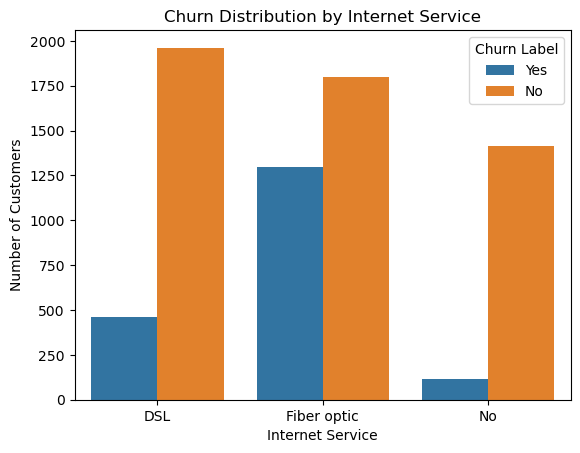

In [30]:
sns.countplot(
    data=eda_df,
    x="Internet Service",
    hue="Churn Label"
)

plt.title("Churn Distribution by Internet Service")
plt.xlabel("Internet Service")
plt.ylabel("Number of Customers")
plt.show()

In [33]:
pd.crosstab(
    eda_df["Tenure Months"],
    eda_df["Churn Label"],
    normalize="index"
).mul(100).head(20)

Churn Label,No,Yes
Tenure Months,,
0,100.000000,0.000000
1,38.009788,61.990212
2,48.319328,51.680672
3,53.000000,47.000000
4,52.840909,47.159091
5,51.879699,48.120301
6,63.636364,36.363636
7,61.068702,38.931298
8,65.853659,34.146341


In [31]:
eda_df.groupby("Churn Label")["Tenure Months"].mean()

Churn Label
No     37.569965
Yes    17.979133
Name: Tenure Months, dtype: float64

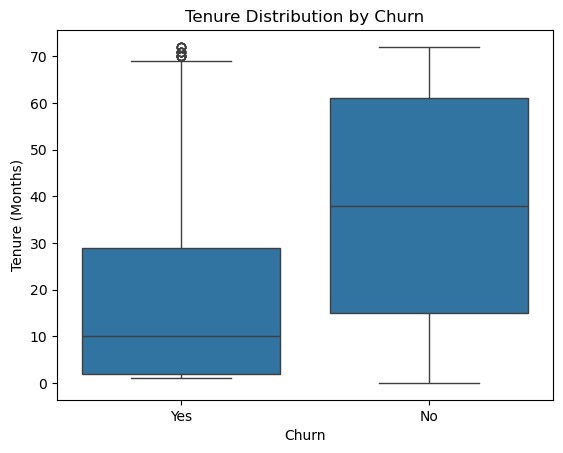

In [32]:
sns.boxplot(
    data=eda_df,
    x="Churn Label",
    y="Tenure Months"
)

plt.title("Tenure Distribution by Churn")
plt.xlabel("Churn")
plt.ylabel("Tenure (Months)")
plt.show()